# FlashEats — Class 5 Investigation
**Mission:** assemble trustworthy evidence about late deliveries.

Rules: no ML for first 90 minutes; preserve raw API responses; state your definition of late; never silently drop failures.

In [1]:
import json, math, sqlite3, time, subprocess, sys
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)

# notebook runs from exercises/, the pack is next to it
BASE = Path("FlashEats_Classroom_Pack_V2")
DB_PATH = BASE / "database" / "flasheats.db"
if not DB_PATH.exists():
    raise FileNotFoundError(f"Database not found at {DB_PATH.resolve()}. Run this notebook from the exercises folder.")
print(BASE, "| database found:", DB_PATH.exists())

FlashEats_Classroom_Pack_V2 | database found: True


## Challenge 1 — How large is the late-delivery problem?
Write down your definition of late, denominator, cancellation policy, and missing-timestamp policy before querying.

My definitions, written before querying:

- **Late** = delivered after the promised ETA, so `actual_delivery_at - promised_eta > 0 min`. I also report the > 10 min version because not everyone agrees a 1-minute miss counts.
- **Denominator** = unique orders (one per `order_id`) with status delivered (ignoring case and spaces) and a non-null `actual_delivery_at`.
- **Cancelled orders** are excluded from the rate because they were never delivered. I count them separately.
- **Missing delivery timestamp**: excluded and reported as unknown. I don't treat them as on time.

In [2]:
con = sqlite3.connect(DB_PATH)
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", con)

,name
0,customers
1,drivers
2,restaurants
3,orders


In [3]:
# First check the grain: is one row one order?
pd.read_sql("""
SELECT COUNT(*) AS rows, COUNT(DISTINCT order_id) AS unique_orders,
       SUM(actual_delivery_at IS NULL) AS missing_actual
FROM orders;
""", con)

,rows,unique_orders,missing_actual
0,1603,1600,105


In [4]:
query = """
-- keep one row per order_id, normalise status, compute delay in minutes
WITH dedup AS (
    SELECT *, ROW_NUMBER() OVER (PARTITION BY order_id ORDER BY rowid) AS rn
    FROM orders
),
o AS (
    SELECT order_id, LOWER(TRIM(final_status)) AS status, actual_delivery_at,
           (julianday(actual_delivery_at) - julianday(promised_eta)) * 24 * 60 AS delay_min
    FROM dedup
    WHERE rn = 1
)
SELECT COUNT(*) AS unique_orders,
       SUM(status = 'cancelled') AS cancelled,
       SUM(status = 'delivered' AND actual_delivery_at IS NULL) AS delivered_missing_time,
       SUM(status = 'delivered' AND actual_delivery_at IS NOT NULL) AS valid_delivered,
       SUM(status = 'delivered' AND delay_min > 0) AS late_any,
       SUM(status = 'delivered' AND delay_min > 10) AS late_over_10,
       ROUND(100.0 * SUM(status = 'delivered' AND delay_min > 0)
             / SUM(status = 'delivered' AND actual_delivery_at IS NOT NULL), 1) AS late_pct
FROM o;
"""
pd.read_sql(query, con)

,unique_orders,cancelled,delivered_missing_time,valid_delivered,late_any,late_over_10,late_pct
0,1600,68,37,1495,843,349,56.4


In [5]:
# Same thing in pandas, as small helpers I can reuse later
def load_clean_orders(con):
    raw = pd.read_sql("SELECT * FROM orders", con)
    df = raw.drop_duplicates("order_id", keep="first").copy()   # 3 duplicate rows, keep first
    for c in ["created_at", "promised_eta", "pickup_at", "actual_delivery_at"]:
        df[c] = pd.to_datetime(df[c], format="mixed", errors="coerce")
    df["status"] = df["final_status"].str.strip().str.lower()
    df["traffic"] = df["traffic_bucket"].str.strip().str.lower()
    df["delay_min"] = (df["actual_delivery_at"] - df["promised_eta"]).dt.total_seconds() / 60
    return raw, df

def valid_delivered(df):
    return df[(df["status"] == "delivered") & df["actual_delivery_at"].notna()]

def late_rate(df, threshold=0):
    v = valid_delivered(df)
    late = int((v["delay_min"] > threshold).sum())
    return {"late_if_over_min": threshold, "late": late, "denominator": len(v), "late_pct": round(100 * late / len(v), 1)}

raw, orders = load_clean_orders(con)

dups = raw[raw["order_id"].duplicated(keep=False)].sort_values("order_id")
print("Duplicated order_ids:", dups["order_id"].unique().tolist())
print("Columns that differ inside a duplicate pair:",
      [c for c in raw.columns if dups.groupby("order_id")[c].nunique().max() > 1])
print("Raw status values:", raw["final_status"].value_counts().to_dict())
print("Raw traffic values:", raw["traffic_bucket"].value_counts().to_dict())

display(pd.DataFrame([late_rate(orders, t) for t in [0, 5, 10, 15]]))

late = valid_delivered(orders).query("delay_min > 0")
print(f"Median lateness among late orders: {late['delay_min'].median():.1f} min")
print("promised_eta before created_at:", int((orders["promised_eta"] < orders["created_at"]).sum()),
      "| delivered before pickup:", int((orders["actual_delivery_at"] < orders["pickup_at"]).sum()))

Duplicated order_ids: ['O00120', 'O00723', 'O01302']
Columns that differ inside a duplicate pair: ['traffic_bucket']
Raw status values: {'delivered': 1530, 'cancelled': 68, 'Delivered': 5}
Raw traffic values: {'medium': 635, 'high': 448, 'low': 381, 'severe': 136, 'HIGH': 3}


,late_if_over_min,late,denominator,late_pct
0,0,843,1495,56.4
1,5,560,1495,37.5
2,10,349,1495,23.3
3,15,208,1495,13.9


Median lateness among late orders: 8.0 min
promised_eta before created_at: 4 | delivered before pickup: 5


,order_id,created_at,promised_eta,actual_delivery_at,delay_min,bad_chronology
103,O00104,2026-08-09 22:19:00,2026-08-09 22:09:00.000000,2026-08-09 23:36:20.740161,87.3,True
101,O00102,2026-08-11 16:41:00,2026-08-11 16:31:00.000000,2026-08-11 17:57:17.661772,86.3,True
100,O00101,2026-08-24 20:59:00,2026-08-24 20:49:00.000000,2026-08-24 22:14:30.685278,85.5,True
102,O00103,2026-08-22 20:11:00,2026-08-22 20:01:00.000000,2026-08-22 21:10:17.342305,69.3,True
1080,O01081,2026-08-13 17:14:00,2026-08-13 18:15:46.613098,2026-08-13 19:06:02.677891,50.3,False
472,O00473,2026-08-14 18:58:00,2026-08-14 20:17:48.000000,2026-08-14 21:04:00.769224,46.2,False


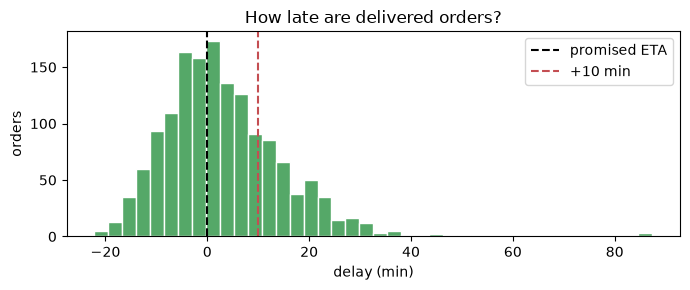

In [6]:
orders["bad_chronology"] = (orders["promised_eta"] < orders["created_at"]) | (orders["actual_delivery_at"] < orders["pickup_at"])
worst = valid_delivered(orders).nlargest(6, "delay_min")[["order_id", "created_at", "promised_eta", "actual_delivery_at", "delay_min", "bad_chronology"]]
display(worst.assign(delay_min=worst["delay_min"].round(1)))

v = valid_delivered(orders)
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(v["delay_min"], bins=40, color="#55A868", edgecolor="white")
ax.axvline(0, color="black", linestyle="--", label="promised ETA")
ax.axvline(10, color="#C44E52", linestyle="--", label="+10 min")
ax.set_xlabel("delay (min)")
ax.set_ylabel("orders")
ax.set_title("How late are delivered orders?")
ax.legend()
plt.tight_layout()
plt.show()

**Result.** The table has 1603 rows for 1600 orders. The 3 duplicates (O00120, O00723, O01302) only differ in `traffic_bucket`, so dedup doesn't change the late rate, but their traffic label is unreliable. After removing 68 cancelled orders and 37 delivered orders with no delivery time, there are 1495 valid delivered orders. **843 of them (56.4%) were late** by the strict definition, but only 349 (23.3%) by more than 10 minutes. The median late order was 8.0 min late.

The worst 4 orders (69 to 87 min late) all have a promised ETA *before* the order was created, so their delay isn't real. I'd report them as bad data rather than as the worst deliveries. The first normal one is O01081 at 50.3 min.

### Checkpoint
Compare counts with another team. If they differ, investigate row grain, duplicates, cancellations, missing timestamps, and definitions.

Things that would make another team's count differ from mine: counting raw rows (1603) instead of orders (1600), matching `'delivered'` case-sensitively (loses 5 `Delivered` rows), keeping the 37 orders with no delivery time in the denominator, or using a different threshold. The threshold matters most: 56.4% at > 0 min vs 23.3% at > 10 min.

## Challenge 2 — Operations says traffic is the cause
Test the claim. Treat traffic/weather/distance as descriptive signals, not causal proof.

In [7]:
def by_dimension(df, col):
    v = valid_delivered(df)
    return v.groupby(col, observed=True).agg(
        orders=("order_id", "count"),
        late_pct=("delay_min", lambda s: round(100 * (s > 0).mean(), 1)),
        median_delay=("delay_min", "median"),
    ).round(1)

orders["created_to_pickup"] = (orders["pickup_at"] - orders["created_at"]).dt.total_seconds() / 60
orders["pickup_to_delivery"] = (orders["actual_delivery_at"] - orders["pickup_at"]).dt.total_seconds() / 60
orders["hour"] = orders["created_at"].dt.hour

display(by_dimension(orders, "traffic").reindex(["low", "medium", "high", "severe"]))
display(by_dimension(orders, "weather_bucket"))
print("Orders with distance exactly 18.0 km:", f"{(orders['distance_km_estimate'] == 18).mean():.1%}")

v = valid_delivered(orders).assign(late=lambda d: d["delay_min"] > 0)
print("Median minutes per stage, on time vs late:")
display(v.groupby("late")[["created_to_pickup", "pickup_to_delivery"]].median().round(1))
print("Median minutes per stage by traffic:")
display(v.groupby("traffic")[["created_to_pickup", "pickup_to_delivery"]].median().reindex(["low", "medium", "high", "severe"]).round(1))

,orders,late_pct,median_delay
traffic,,,
low,360,49.4,-0.1
medium,588,51.4,0.3
high,424,66.5,4.0
severe,123,65.9,4.3


,orders,late_pct,median_delay
weather_bucket,,,
clear,1192,53.3,0.8
heavy_rain,72,73.6,6.6
rain,231,67.1,4.3


Orders with distance exactly 18.0 km: 50.4%
Median minutes per stage, on time vs late:


,created_to_pickup,pickup_to_delivery
late,,
False,19.8,45.3
True,31.9,48.9


Median minutes per stage by traffic:


,created_to_pickup,pickup_to_delivery
traffic,,
low,25.8,43.5
medium,25.9,46.7
high,27.0,53.0
severe,25.5,61.8


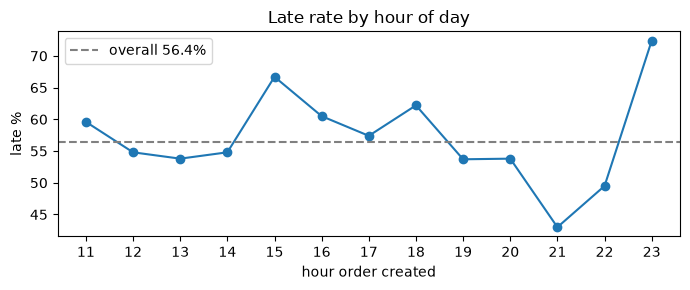

hour,11,12,13,14,15,16,17,18,19,20,21,22,23
orders,94.0,124.0,93.0,73.0,57.0,76.0,129.0,222.0,205.0,173.0,100.0,91.0,58.0
late_pct,59.6,54.8,53.8,54.8,66.7,60.5,57.4,62.2,53.7,53.8,43.0,49.5,72.4
median_delay,1.9,1.0,0.7,0.9,4.0,2.4,3.0,3.2,0.9,0.5,-1.5,-0.0,4.6


In [8]:
hourly = by_dimension(orders, "hour")
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(hourly.index, hourly["late_pct"], marker="o")
overall = late_rate(orders)["late_pct"]
ax.axhline(overall, color="grey", linestyle="--", label=f"overall {overall}%")
ax.set_xticks(hourly.index)
ax.set_xlabel("hour order created")
ax.set_ylabel("late %")
ax.set_title("Late rate by hour of day")
ax.legend()
plt.tight_layout()
plt.show()
display(hourly.T)

Traffic is associated with lateness: 49.4% late in low traffic vs 66.5% in high and 65.9% in severe. But traffic mainly stretches the road leg (median pickup-to-delivery 43.5 min in low vs 61.8 min in severe), and time before pickup is flat across traffic levels (25.5 to 27.0 min). The bigger difference between on-time and late orders is *before pickup*: 31.9 min for late orders vs 19.8 min for on-time ones. The road leg differs less (48.9 vs 45.3). Rain also looks bad (67.1% late, heavy rain 73.6%), but it probably comes with traffic, so I can't split them. Distance isn't usable because 50.4% of orders are exactly 18.0 km. By hour, the late rate moves between 43.0% (21:00) and 72.4% (23:00) without a clear rush-hour effect.

So traffic is a real factor, but it doesn't look like the main one. My working hypothesis is that most delay happens at the restaurant / pickup stage. The alternative I can't rule out is that dispatch assigns drivers late or far away, which would look the same in this table. None of this is causal. These are raw comparisons with overlapping factors.

## Challenge 3 — Customer Support disagrees
Inspect support tickets. What are customers actually complaining about? Are ticket records unique?

In [9]:
tickets = pd.read_csv(BASE / "data" / "support_tickets.csv")
display(tickets.head())

print("rows:", len(tickets), "| unique ticket_id:", tickets["ticket_id"].nunique(),
      "| exact duplicate rows:", tickets.duplicated().sum(), "| no order_id:", tickets["order_id"].isna().sum())
tk = tickets.drop_duplicates().copy()
tk["category_norm"] = tk["category"].str.strip().str.lower().str.replace(" ", "_")   # case/space only
display(tk["category_norm"].value_counts())

linked = tk.merge(orders[["order_id", "status", "delay_min", "created_to_pickup", "promised_eta"]], on="order_id", how="inner")
with_time = linked.dropna(subset=["delay_min"])
print(f"Linked tickets: {len(linked)} | with delivery time: {len(with_time)} | on late orders: {(with_time['delay_min'] > 0).sum()} "
      f"({100 * (with_time['delay_min'] > 0).mean():.1f}%)")
print("Tickets raised before the promised ETA:",
      int((pd.to_datetime(linked["created_at"]) < linked["promised_eta"]).sum()), "of", len(linked))

,ticket_id,order_id,created_at,category,customer_message
0,T00001,NaN,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,NaN,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still n...
2,T00003,NaN,2026-08-25T18:22:00,status_mismatch,The app says picking up but the restaurant say...
3,T00004,O00037,2026-08-09T21:09:00,Late Delivery,The rider has not moved for 15 minutes.
4,T00005,O00040,2026-08-11T20:15:00,late_delivery,My order is already past the promised time.


rows: 202 | unique ticket_id: 201 | exact duplicate rows: 1 | no order_id: 3


category_norm
late_delivery        39
eta_changed          37
restaurant_delay     37
ready_but_waiting    33
status_mismatch      29
driver_not_moving    25
eta_issue             1
Name: count, dtype: int64

Linked tickets: 198 | with delivery time: 197 | on late orders: 163 (82.7%)
Tickets raised before the promised ETA: 192 of 198


201 unique tickets after dropping one exact duplicate (T00013 appears twice). 3 have no `order_id`. The categories are fairly even: late_delivery 39, eta_changed 37, restaurant_delay 37, ready_but_waiting 33, status_mismatch 29, driver_not_moving 25, plus one "ETA issue" that I left alone because merging it into eta_changed is Support's call. I counted "Late Delivery" (T00004) as late_delivery, but its message is "The rider has not moved for 15 minutes", so it may really be a driver_not_moving complaint. Over half of the complaints are about the restaurant, the handoff or the ETA moving, and fewer are plain "it's late". That fits the pickup-stage finding better than the traffic story.

163 of 197 linked tickets with a delivery time (82.7%) are on late orders, so tickets are mostly about real delays. One odd thing: 192 of 198 linked tickets were created *before* the promised ETA, even ones saying "past the promised time". That suggests the ETA the customer sees in the app isn't the `promised_eta` we store. I'd want to check that with the app team.

## Challenge 4 — Retrieve Dispatch data reliably

In [10]:
api_proc = subprocess.Popen([sys.executable, str(BASE / "api" / "mock_dispatch_api.py")],
                            stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
# wait until the API answers instead of sleeping a fixed time
for _ in range(40):
    try:
        health = requests.get("http://127.0.0.1:8000/health", timeout=1)
        if health.ok:
            break
    except requests.ConnectionError:
        pass
    time.sleep(0.25)
else:
    raise RuntimeError("mock API did not start")
health.json()

{'service': 'flasheats-dispatch-api', 'status': 'ok'}

In [11]:
url = "http://127.0.0.1:8000/dispatch/orders"
r = requests.get(url, params={"page": 1, "page_size": 50}, timeout=10)
print(r.status_code); payload = r.json(); print(payload.keys(), len(payload.get("data", [])), payload.get("has_more"))

200
dict_keys(['data', 'has_more', 'page', 'page_size', 'total_records']) 50 True


### Your task
Implement pagination + retry + raw-page preservation. Refuse to claim success if ingestion is incomplete.

In [12]:
RAW_DIR = BASE / "student_output" / "raw_dispatch"
RAW_DIR.mkdir(parents=True, exist_ok=True)

def fetch_all_dispatch_orders(page_size=50, max_retries=4):
    # page through the API, retry 429/5xx and network errors, save each good page raw
    records, saved, retry_events, totals = [], [], [], set()
    page = 1
    while True:
        for attempt in range(1, max_retries + 2):
            try:
                resp = requests.get(url, params={"page": page, "page_size": page_size}, timeout=10)
                status = resp.status_code
            except requests.RequestException as e:
                resp, status = None, type(e).__name__
            if status == 200:
                break
            if resp is not None and status not in (429, 500, 502, 503):
                raise RuntimeError(f"page {page}: HTTP {status}, not retryable")
            try:
                body = resp.json()
            except (AttributeError, ValueError):   # no response at all, or not JSON
                body = {}
            wait = body.get("retry_after_seconds", 0.5 * 2 ** (attempt - 1))   # server hint, else backoff
            retry_events.append({"page": page, "attempt": attempt, "status": status,
                                 "error": body.get("error"), "waited_s": wait})
            if attempt <= max_retries:
                print(f"page {page} attempt {attempt}: {status}, retrying in {wait}s")
                time.sleep(wait)
        else:
            raise RuntimeError(f"page {page} failed {max_retries + 1} times, stopping. Data is incomplete.")

        body = resp.json()
        out = RAW_DIR / f"page_{page:03d}.json"
        out.write_text(resp.text)
        saved.append(out)
        records.extend(body["data"])
        totals.add(body["total_records"])
        if not body["has_more"]:
            return records, {"totals": totals, "pages": page, "page_size": page_size,
                             "saved": saved, "retry_events": retry_events}
        page += 1

dispatch_records, info = fetch_all_dispatch_orders()
print("retrieved", len(dispatch_records), "records over", info["pages"], "pages")
print("total_records reported per page:", info["totals"])
display(pd.DataFrame(info["retry_events"]))

page 3 attempt 1: 500, retrying in 0.5s


page 5 attempt 1: 429, retrying in 1s


retrieved 1600 records over 32 pages
total_records reported per page: {1600}


,page,attempt,status,error,waited_s
0,3,1,500,temporary upstream failure,0.5
1,5,1,429,rate limit exceeded,1.0


In [13]:
def check(name, ok, evidence):
    return {"check": name, "status": "PASS" if ok else "FAIL", "evidence": evidence}

dispatch = pd.DataFrame(dispatch_records)
total = max(info["totals"])
expected_pages = math.ceil(total / info["page_size"])
from_disk = sum(len(json.loads(p.read_text())["data"]) for p in info["saved"])
ids_api, ids_db = set(dispatch["order_id"]), set(orders["order_id"])

completeness = pd.DataFrame([
    check("same total_records on every page", len(info["totals"]) == 1, f"values seen: {sorted(info['totals'])}"),
    check("count == total_records", len(dispatch) == total, f"{len(dispatch)} / {total}"),
    check("order_id unique", dispatch["order_id"].is_unique, f"{dispatch['order_id'].nunique()} unique"),
    check("all pages saved", len(info["saved"]) == expected_pages, f"{len(info['saved'])} of {expected_pages} pages"),
    check("saved files re-read", from_disk == len(dispatch), f"{from_disk} records on disk"),
    check("matches orders table", ids_api == ids_db, f"{len(ids_api & ids_db)} shared, {len(ids_api ^ ids_db)} unmatched"),
])
display(completeness)
if (completeness["status"] != "PASS").any():
    raise RuntimeError("Ingestion incomplete, not claiming success.")

recon = dispatch.merge(orders[["order_id", "status", "driver_id"]], on="order_id", suffixes=("", "_orders"), validate="one_to_one")
display(pd.crosstab(recon["dispatch_status"], recon["status"]))
print("reassigned orders:", int(recon["reassigned_at"].notna().sum()))
print("orders.driver_id = current dispatch driver:", int((recon["driver_id_orders"] == recon["driver_id"]).sum()),
      "| = original driver:", int((recon["driver_id_orders"] == recon["original_driver_id"]).sum()))

,check,status,evidence
0,same total_records on every page,PASS,values seen: [1600]
1,count == total_records,PASS,1600 / 1600
2,order_id unique,PASS,1600 unique
3,all pages saved,PASS,32 of 32 pages
4,saved files re-read,PASS,1600 records on disk
5,matches orders table,PASS,"1600 shared, 0 unmatched"


status,cancelled,delivered
dispatch_status,,
cancelled,68,0
completed,0,1532


reassigned orders: 95
orders.driver_id = current dispatch driver: 1502 | = original driver: 1597


All 1600 dispatch records came through: 32 pages of 50, every page reported the same `total_records` (1600), 1600 unique order IDs, all 32 raw pages saved in `student_output/raw_dispatch/` and re-readable. The retry table shows page 3 failed with HTTP 500 (I retried after a 0.5 s backoff) and page 5 with HTTP 429 (I waited the 1 s `retry_after_seconds` the server gave). Both worked on the second attempt. If a page failed 5 times, the function raises instead of returning what it has, and the check cell raises if any check fails.

The IDs match the orders table exactly and dispatch status lines up with order status (1532 completed/delivered, 68 cancelled). The one mismatch is drivers: 95 orders were reassigned, and `orders.driver_id` holds the original driver (1597 matches) rather than the current one (1502 matches).

## Challenge 5 — Driver events
What is observed vs inferred? Can you find a reliable driver-arrival-at-restaurant event?

In [14]:
with open(BASE / "data" / "driver_events.json") as f:
    driver_events = json.load(f)
display(driver_events[0]["events"][:3])

ev = pd.DataFrame([{"driver_id": d["driver_id"], **e} for d in driver_events for e in d["events"]])
ev["timestamp"] = pd.to_datetime(ev["timestamp"], format="mixed", errors="coerce")
print("event types:", ev["type"].value_counts().to_dict())
print("any arrival-type event:", ev["type"].str.contains("arriv|restaurant").any())

# explicit events vs the orders table
t = ev.pivot_table(index="order_id", columns="type", values="timestamp", aggfunc="first")
o = orders.set_index("order_id")
print("picked_up != orders.pickup_at:", int(((t["picked_up"] - o["pickup_at"]).abs() > pd.Timedelta(seconds=1)).sum()))
print("delivered != orders.actual_delivery_at:", int(((t["delivered"] - o["actual_delivery_at"]).abs() > pd.Timedelta(seconds=1)).sum()))
print("delivered event but no actual_delivery_at:", int((t["delivered"].notna() & o["actual_delivery_at"].reindex(t.index).isna()).sum()))
print("pickup before assignment:", int((t["picked_up"] < t["assigned"]).sum()))

[{'order_id': 'O00162',
  'type': 'assigned',
  'timestamp': '2026-08-26T17:53:25.977803'},
 {'order_id': 'O00162',
  'type': 'gps_ping',
  'timestamp': '2026-08-26T18:10:59.372420',
  'lat': 12.826339,
  'lon': 77.448282},
 {'order_id': 'O00162',
  'type': 'gps_ping',
  'timestamp': '2026-08-26T18:28:32.767037',
  'lat': 12.876013,
  'lon': 77.477707}]

event types: {'gps_ping': 5371, 'assigned': 1600, 'picked_up': 1532, 'delivered': 1532}
any arrival-type event: False
picked_up != orders.pickup_at: 5
delivered != orders.actual_delivery_at: 0
delivered event but no actual_delivery_at: 37
pickup before assignment: 14


In [15]:
# inferred: how close do GPS pings get to the restaurant?
def km_between(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    h = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 6371 * 2 * np.arcsin(np.sqrt(h))

rest = pd.read_sql("SELECT restaurant_id, lat AS r_lat, lon AS r_lon FROM restaurants", con)
bad_rest = rest[(rest["r_lat"].abs() > 90) | (rest["r_lon"].abs() > 180)]
print("restaurants with impossible coordinates:")
display(bad_rest)

pings = ev[ev["type"] == "gps_ping"].merge(orders[["order_id", "restaurant_id"]], on="order_id").merge(rest, on="restaurant_id")
pings["km"] = km_between(pings["lat"], pings["lon"], pings["r_lat"], pings["r_lon"])
far = pings[pings["km"] > 100]
print("pings > 100 km from their restaurant:", len(far), "| restaurants involved:", sorted(far["restaurant_id"].unique()))

ok = pings[~pings["restaurant_id"].isin(bad_rest["restaurant_id"])]   # drop the 2 bad restaurants
closest = ok.groupby("order_id")["km"].min()
print("orders with pings (valid restaurant coords):", len(closest), "| pings per order:", ok.groupby("order_id").size().agg(["min", "max"]).tolist())
print("closest ping within 0.5 km of restaurant:", int((closest <= 0.5).sum()), "orders | median closest:", round(closest.median(), 1), "km")

restaurants with impossible coordinates:


,restaurant_id,r_lat,r_lon
6,R007,95.120000,77.694095
18,R019,12.847954,190.330000


pings > 100 km from their restaurant: 163 | restaurants involved: ['R007', 'R019']
orders with pings (valid restaurant coords): 1481 | pings per order: [2, 5]
closest ping within 0.5 km of restaurant: 17 orders | median closest: 4.0 km


| Event / fact | Observed or inferred | Source | Concern |
|---|---|---|---|
| Driver assigned | Observed | `driver_events.json` `assigned`, dispatch `assigned_at` | only the current driver has an event, not the original one for the 95 reassigned orders |
| Driver at restaurant | Not observed. Could only be inferred from GPS | GPS pings vs restaurant lat/lon | no arrival event; pings are sparse and rarely near the restaurant |
| Picked up | Observed | `picked_up` event, `orders.pickup_at` | 5 orders disagree with the orders table; 14 pickups logged before assignment |
| Delivered | Observed | `delivered` event, `orders.actual_delivery_at` | matches exactly, but 37 delivered events have no `actual_delivery_at` in orders |

I could not find a reliable driver-arrival-at-restaurant event. There isn't an explicit one, and GPS doesn't fill the gap. First, two restaurants have impossible coordinates in the restaurants table (R007 has lat 95.12, R019 has lon 190.33), and all 163 pings that look more than 100 km away belong to their orders, so the problem is the restaurant locations. I left those two restaurants out. For the rest, only 17 orders ever get a ping within 0.5 km of the restaurant and the median closest ping is 4.0 km away. The 37 delivered events without an `actual_delivery_at` suggest the order system dropped those timestamps, which I would check with the order-platform owner before backfilling.

## Final FDE recommendation
Prepare one slide: problem size, evidence, uncertainty, missing instrumentation, next step.

**Would you build the AI delay predictor now? Why or why not?**

**Problem size:** 56.4% of 1495 valid delivered orders were late (> 0 min), 23.3% by more than 10 min. The median late order was 8.0 min late.

**Evidence:** late orders spend much longer before pickup (31.9 vs 19.8 min). Traffic and rain are associated with more lateness, mostly on the road leg. Tickets mostly complain about the restaurant/handoff and the ETA moving.

**Uncertainty:** I can't tell whether the pre-pickup wait is the restaurant or dispatch. I can't see which ETA the customer was shown. 37 deliveries have no timestamp and 9 rows have impossible timestamps.

**Missing instrumentation:** driver-arrived-at-restaurant and food-ready events, a log of every ETA shown to the customer, the current driver on the order, a real distance instead of the 18 km default, and fixed coordinates for R007 and R019.

**Next step:** agree one late definition with an owner and start logging the pickup-stage events.

**Would I build the AI delay predictor now?** No. The label isn't agreed (56.4% vs 23.3%), the stage with most of the delay has no events explaining it, and some inputs are defaulted (distance) or stale (driver). I'd fix the definition and the pickup-stage events first and then look again.

In [16]:
# cleanup: stop the mock API and close the database
api_proc.terminate()
api_proc.wait(timeout=10)
con.close()
print("API stopped, return code", api_proc.returncode)

API stopped, return code -15
